In [36]:
print("="*60)
print("DRIVER REVENUE OPTIMIZATION & RIDE OPERATIONS ANALYTICS")
print("="*60)

"""
Business Objectives

1. Identify the most profitable driving periods.
2. Analyze factors affecting driver earnings.
3. Understand demand patterns.
4. Study tip behavior and payment preferences.
5. Generate operational recommendations.
"""

# importing all the necessary libs

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind, f_oneway
import warnings 
warnings.filterwarnings('ignore')

DRIVER REVENUE OPTIMIZATION & RIDE OPERATIONS ANALYTICS


In [ ]:
print("="*60)
print("1. DATA LOADING & INITIAL INSPECTION")
print("="*60)

#loading necessary data
df = pd.read_csv('./data/raw/yellow_tripdata_2020-01.csv')

df.shape

df.info()

df.head()

df.describe()

1. DATA LOADING & INITIAL INSPECTION
<class 'pandas.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               float64
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     str    
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(13), int64(2), str(3)
memory usage: 879.6 MB


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,6.339567e+06,6.339567e+06,6.405008e+06,6.339567e+06,6.405008e+06,6.405008e+06,6.339567e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06
mean,1.669624e+00,1.515333e+00,2.929644e+00,1.059908e+00,1.647323e+02,1.626627e+02,1.270298e+00,1.269411e+01,1.115456e+00,4.923182e-01,2.189342e+00,3.488395e-01,2.979870e-01,1.866315e+01,2.275662e+00
std,4.703484e-01,1.151594e+00,8.315911e+01,8.118432e-01,6.554374e+01,6.991261e+01,4.739985e-01,1.212730e+01,1.260054e+00,7.374184e-02,2.760028e+00,1.766978e+00,3.385937e-02,1.475736e+01,7.352646e-01
min,1.000000e+00,0.000000e+00,-3.062000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.238000e+03,-2.700000e+01,-5.000000e-01,-9.100000e+01,-3.574000e+01,-3.000000e-01,-1.242300e+03,-2.500000e+00
25%,1.000000e+00,1.000000e+00,9.600000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01,2.500000e+00
50%,2.000000e+00,1.000000e+00,1.600000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,9.000000e+00,5.000000e-01,5.000000e-01,1.950000e+00,0.000000e+00,3.000000e-01,1.430000e+01,2.500000e+00
75%,2.000000e+00,2.000000e+00,2.930000e+00,1.000000e+00,2.340000e+02,2.340000e+02,2.000000e+00,1.400000e+01,2.500000e+00,5.000000e-01,2.860000e+00,0.000000e+00,3.000000e-01,1.980000e+01,2.500000e+00
max,2.000000e+00,9.000000e+00,2.102401e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,4.265000e+03,1.130100e+02,3.080000e+01,1.100000e+03,9.105000e+02,3.000000e-01,4.268300e+03,2.750000e+00


In [38]:
print("="*60)
print("2. Data Preparation")
print("="*60)

print("-"*60)
print("2.1 Initial Cleaning")
print("-"*60)

# Store initial row count before any cleaning
initial_rows = len(df)

# Missing values summary
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': round(df.isna().sum() / len(df) * 100, 2)
}).sort_values(
    by='Missing Count',
    ascending=False
)

display(missing_summary)

# Duplicate rows check
duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")

# Cleaning summary (before actual cleaning)
cleaning_summary = pd.DataFrame({
    'Metric': [
        'Initial Rows',
        'Duplicate Rows'
    ],
    'Value': [
        initial_rows,
        duplicate_rows
    ]
})

display(cleaning_summary)

2. Data Preparation
------------------------------------------------------------
2.1 Initial Cleaning
------------------------------------------------------------


,Missing Count,Missing %
VendorID,65441,1.02
passenger_count,65441,1.02
payment_type,65441,1.02
RatecodeID,65441,1.02
store_and_fwd_flag,65441,1.02
tpep_pickup_datetime,0,0.00
trip_distance,0,0.00
tpep_dropoff_datetime,0,0.00
PULocationID,0,0.00
DOLocationID,0,0.00


Duplicate Rows: 12949


,Metric,Value
0,Initial Rows,6405008
1,Duplicate Rows,12949


In [39]:
print("-"*60)
print("2.2 Feature Engineering")
print("-"*60)

df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_weekday'] = df['pickup_datetime'].dt.day_name()
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_date'] = df['pickup_datetime'].dt.date

# cleaning the dataset to only include trips from January 2020
df = df[
    (df['pickup_date'] >= pd.to_datetime('2020-01-01').date())
    &
    (df['pickup_date'] <= pd.to_datetime('2020-01-31').date())
]


df['pickup_day'] = df['pickup_datetime'].dt.day

df['trip_duration'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds() / 60
df['tip_pct'] = (df['tip_amount'] / df['total_amount']) * 100

df.isnull().sum()
# 65441*100/len(df) = 1.02
#dropping null values because weights only 1.02% of whole df
df.dropna(inplace=True)
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')

distance_bins = [0,2,5,10,15,20,30,float('inf')]
distance_labels = [ '0-2', '2-5', '5-10', '10-15', '15-20', '20-30', '30+']

df['distance_bucket'] = pd.cut(
    df['trip_distance'],
    bins=distance_bins,
    labels=distance_labels
)

duration_bins = [ 0, 10, 20, 30, 45, 60, float('inf')]
duration_labels = [ '0-10', '10-20', '20-30', '30-45', '45-60', '60+']

df['duration_bucket'] = pd.cut(
    df['trip_duration'],
    bins=duration_bins,
    labels=duration_labels
)

#time-series buckets
def assign_time_period(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['time_period'] = (
    df['pickup_hour']
    .apply(assign_time_period)
)

print("-"*60)
print("2.3 Data Validation")
print("-"*60)

negative_distance = (df['trip_distance'] <= 0).sum()
negative_duration = (df['trip_duration'] <= 0).sum()
negative_fare = (df['fare_amount'] <= 0).sum()
negative_revenue = (df['total_amount'] <= 0).sum()

print(f"Negative Distance : {negative_distance}")
print(f"Negative Duration : {negative_duration}")
print(f"Negative Fare     : {negative_fare}")
print(f"Negative Revenue  : {negative_revenue}")

# Remove invalid trips
df = df[
    (df['trip_distance'] > 0) &
    (df['trip_duration'] > 0) &
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0)
]

print(f"\nRows After Validation: {len(df):,}")

------------------------------------------------------------
2.2 Feature Engineering
------------------------------------------------------------
------------------------------------------------------------
2.3 Data Validation
------------------------------------------------------------
Negative Distance : 66441
Negative Duration : 3907
Negative Fare     : 20508
Negative Revenue  : 19439

Rows After Validation: 6,253,136


In [40]:
print("="*60)
print("3. KPI CALCULATION & DESCRIPTIVE ANALYTICS")
print("="*60)

total_revenue = df['total_amount'].sum()
total_trips = len(df)
avg_fare = df['fare_amount'].mean()
avg_tip = df['tip_amount'].mean()
avg_distance = df['trip_distance'].mean()
avg_duration = df['trip_duration'].mean()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Trips',
        'Average Fare',
        'Average Tip',
        'Average Distance',
        'Average Duration (min)'
    ],
    'Value': [
        round(total_revenue, 2),
        total_trips,
        round(avg_fare, 2),
        round(avg_tip, 2),
        round(avg_distance, 2),
        round(avg_duration, 2)
    ]
})

display(kpi_summary)

3. KPI CALCULATION & DESCRIPTIVE ANALYTICS


,Metric,Value
0,Total Revenue,1.151523e+08
1,Total Trips,6.253136e+06
2,Average Fare,1.240000e+01
3,Average Tip,2.210000e+00
4,Average Distance,2.880000e+00
5,Average Duration (min),1.588000e+01


In [55]:
print("="*60)
print("4. Driver Revenue Optimization & Ride Operations Analytics")
print("="*60)

# Hourly Analysis
hourly_summary = (
    df.groupby('pickup_hour')
    .agg(
        total_revenue=('total_amount', 'sum'),
        avg_revenue=('total_amount', 'mean'),
        trip_count=('total_amount', 'count')
    )
    .reset_index()
)

# Weekday Analysis
weekday_summary = (
    df.groupby('pickup_weekday')
    .agg(
        total_revenue=('total_amount', 'sum'),
        avg_revenue=('total_amount', 'mean'),
        trip_count=('total_amount', 'count')
    )
    .reset_index()
)

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_summary['pickup_weekday'] = pd.Categorical(
    weekday_summary['pickup_weekday'],
    categories=weekday_order,
    ordered=True
)

weekday_summary = weekday_summary.sort_values('pickup_weekday')

# Monthly Analysis
monthly_summary = (
    df.groupby('pickup_month')
    .agg(
        total_revenue=('total_amount', 'sum'),
        avg_revenue=('total_amount', 'mean'),
        trip_count=('total_amount', 'count')
    )
    .reset_index()
)

# Duration Analysis
duration_summary = (
    df.groupby('duration_bucket')
    .agg(
        total_revenue=('total_amount', 'sum'),
        avg_revenue=('total_amount', 'mean'),
        avg_tip=('tip_amount', 'mean'),
        trip_count=('total_amount', 'count')
    )
    .reset_index()
)

# Distance Analysis
distance_summary = (
    df.groupby('distance_bucket')
    .agg(
        total_revenue=('total_amount', 'sum'),
        avg_revenue=('total_amount', 'mean'),
        avg_tip=('tip_amount', 'mean'),
        trip_count=('total_amount', 'count')
    )
    .reset_index()
)

hourly_tip_summary = (
    df.groupby('pickup_hour')
    .agg(
        avg_tip=('tip_amount','mean'),
        avg_tip_pct=('tip_pct','mean'),
        total_tip=('tip_amount','sum')
    )
    .reset_index()
)

payment_summary = (
    df.groupby('payment_type')
    .agg(
        avg_tip=('tip_amount','mean'),
        avg_tip_pct=('tip_pct','mean'),
        total_revenue=('total_amount','sum'),
        trip_count=('total_amount','count')
    )
    .reset_index()
)

passenger_summary = (
    df.groupby('passenger_count')
    .agg(
        total_revenue=('total_amount','sum'),
        avg_revenue=('total_amount','mean'),
        avg_tip=('tip_amount','mean'),
        trip_count=('total_amount','count')
    )
    .reset_index()
)

distance_tip_summary = (
    df.groupby('distance_bucket')
    .agg(
        avg_tip=('tip_amount','mean'),
        avg_tip_pct=('tip_pct','mean'),
        trip_count=('total_amount','count')
    )
    .reset_index()
)

time_period_summary = (
    df.groupby('time_period')
    .agg(
        avg_revenue=('total_amount','mean')
    )
    .reset_index()
)

daily_summary = (
    df.groupby('pickup_date')
    .agg(
        total_revenue=('total_amount','sum'),
        trip_count=('total_amount','count'),
        avg_revenue=('total_amount','mean')
    )
    .reset_index()
)
daily_summary['revenue_ma7'] = (
    daily_summary['total_revenue']
    .rolling(7)
    .mean()
)

daily_summary['trip_ma7'] = (
    daily_summary['trip_count']
    .rolling(7)
    .mean()
)

4. Driver Revenue Optimization & Ride Operations Analytics


In [56]:
monthly_summary 

,pickup_month,total_revenue,avg_revenue,trip_count
0,1,1.151523e+08,18.415126,6253136


Text(0.5, 0, 'Distance (miles)')

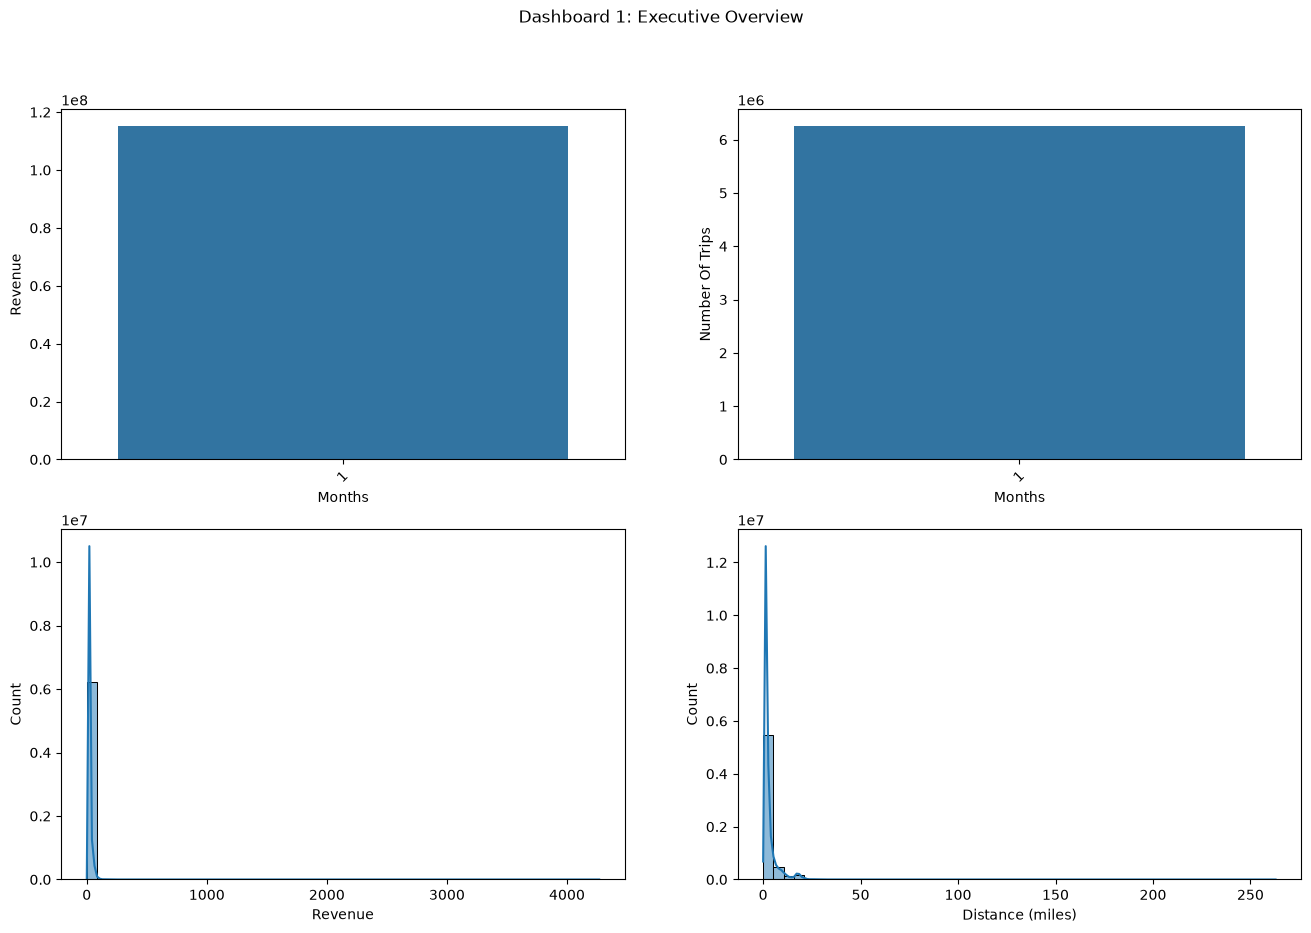

In [42]:
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Dashboard 1: Executive Overview")

ax1 = sns.barplot(x = monthly_summary['pickup_month'], y= monthly_summary['total_revenue'], ax=axes[0,0])
ax1.tick_params(axis= 'x', rotation = 45)
ax1.set_xlabel("Months")
ax1.set_ylabel("Revenue")

ax2 = sns.barplot(x = monthly_summary['pickup_month'], y= monthly_summary['trip_count'], ax=axes[0,1])
ax2.tick_params(axis= 'x', rotation = 45)
ax2.set_xlabel("Months")
ax2.set_ylabel("Number Of Trips")

ax3 = sns.histplot(df['total_amount'], bins=50, kde=True, ax=axes[1,0])
ax3.set_xlabel("Revenue")

ax4 = sns.histplot(df['trip_distance'], bins=50, kde=True, ax=axes[1,1])
ax4.set_xlabel("Distance (miles)")


Text(0, 0.5, 'Revenue')

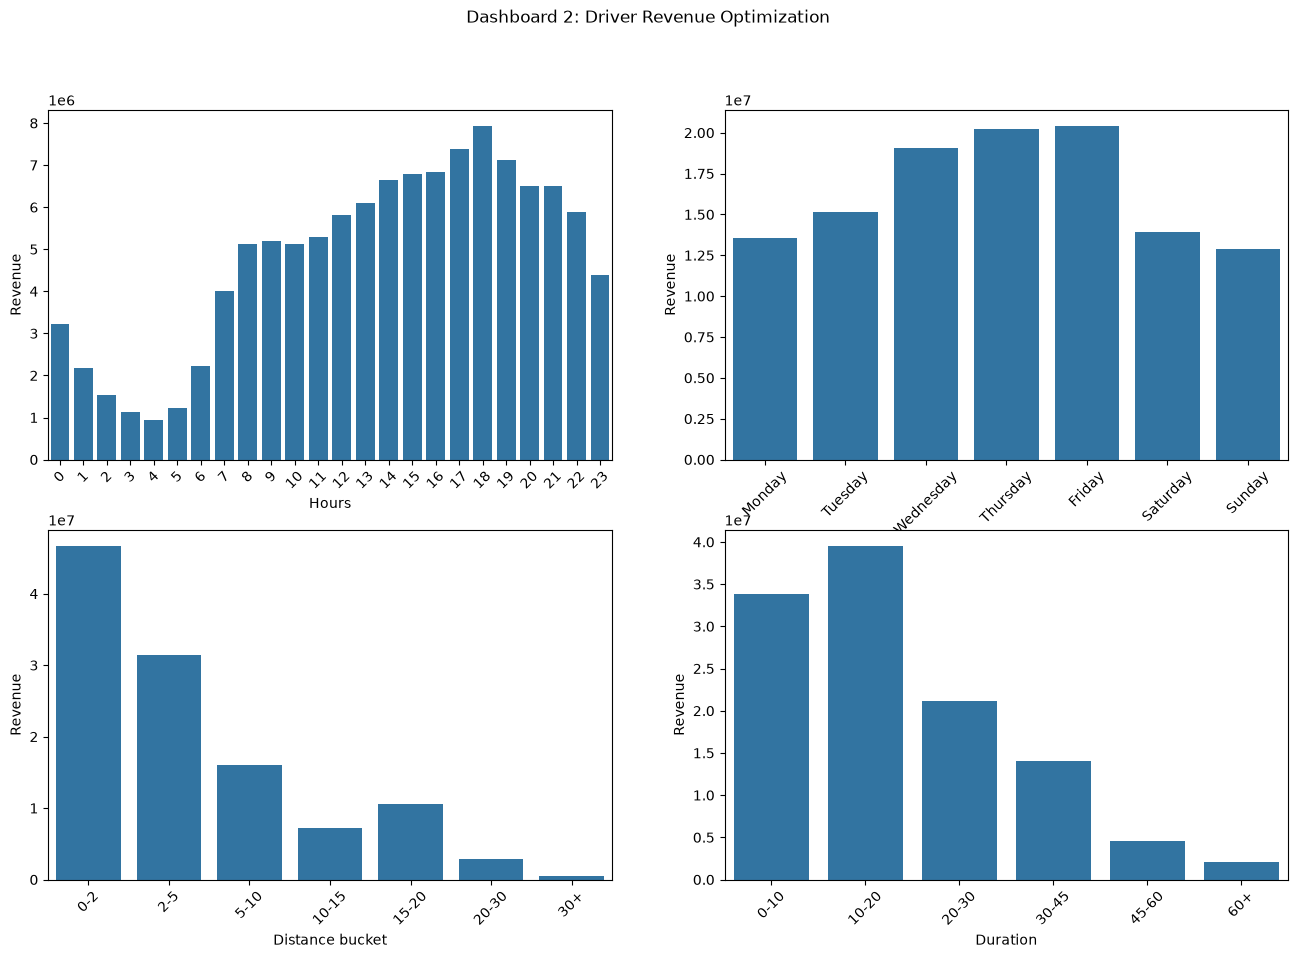

In [43]:
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Dashboard 2: Driver Revenue Optimization")

ax1 = sns.barplot(x= hourly_summary['pickup_hour'] , y= hourly_summary['total_revenue'], ax=axes[0,0])
ax1.tick_params(axis= 'x', rotation = 45)
ax1.set_xlabel("Hours")
ax1.set_ylabel("Revenue")

ax2 = sns.barplot(x= weekday_summary['pickup_weekday'] , y= weekday_summary['total_revenue'], ax=axes[0,1])
ax2.tick_params(axis= 'x', rotation = 45)
ax2.set_xlabel("Day")
ax2.set_ylabel("Revenue")

ax3 = sns.barplot(x= distance_summary['distance_bucket'] , y= distance_summary['total_revenue'], ax=axes[1,0])
ax3.tick_params(axis= 'x', rotation = 45)
ax3.set_xlabel("Distance bucket")
ax3.set_ylabel("Revenue")

ax4 = sns.barplot(x= duration_summary['duration_bucket'] , y= duration_summary['total_revenue'], ax=axes[1,1])
ax4.tick_params(axis= 'x', rotation = 45)
ax4.set_xlabel("Duration")
ax4.set_ylabel("Revenue")

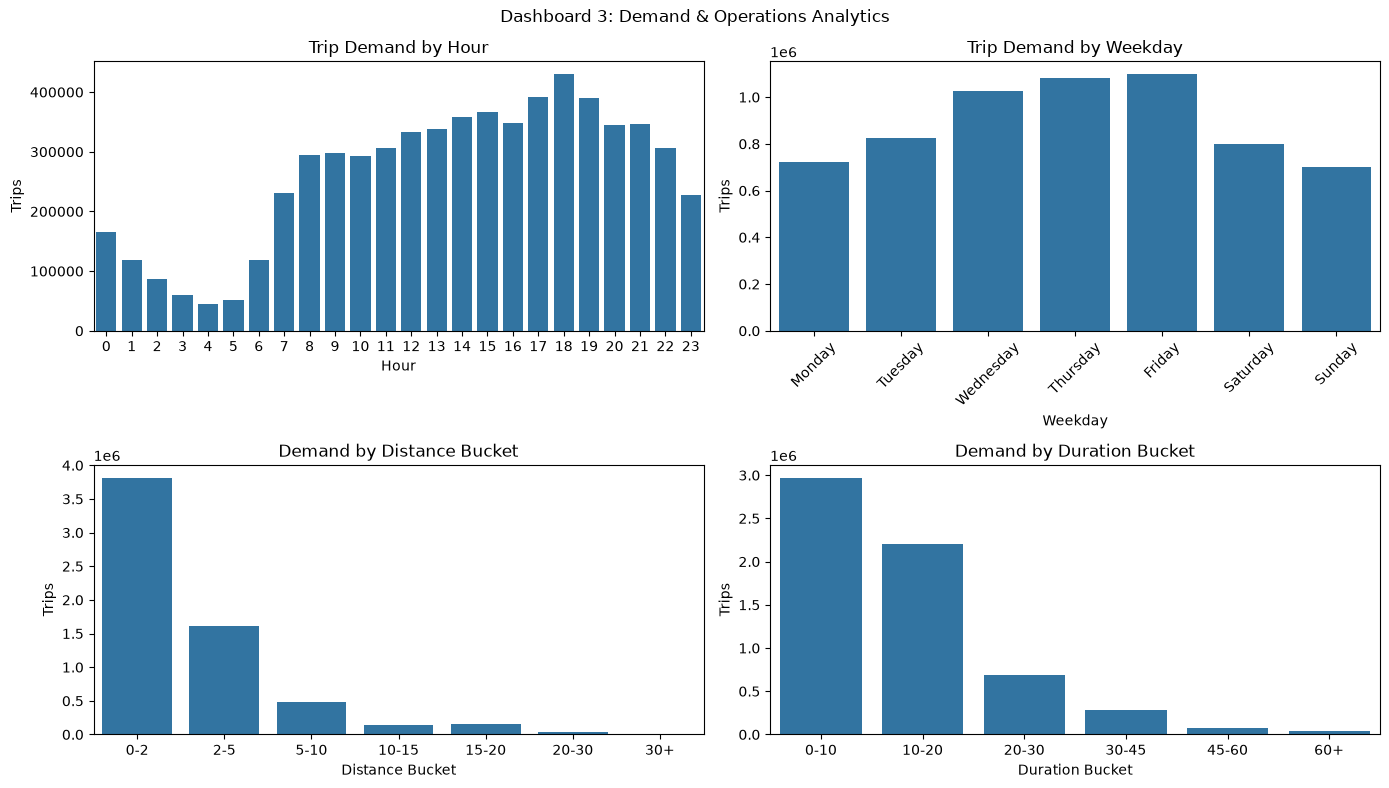

In [44]:
fig, axes = plt.subplots(2,2,figsize=(14,8))
fig.suptitle("Dashboard 3: Demand & Operations Analytics")

# Trips by Hour
ax1 = sns.barplot(x=hourly_summary['pickup_hour'], y=hourly_summary['trip_count'], ax=axes[0,0])
ax1.set_title("Trip Demand by Hour")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Trips")

ax2 = sns.barplot(x=weekday_summary['pickup_weekday'], y=weekday_summary['trip_count'], ax=axes[0,1])
ax2.tick_params(axis='x', rotation=45)
ax2.set_title("Trip Demand by Weekday")
ax2.set_xlabel("Weekday")
ax2.set_ylabel("Trips")

ax3 = sns.barplot(x=distance_summary['distance_bucket'], y=distance_summary['trip_count'], ax=axes[1,0])
ax3.set_title("Demand by Distance Bucket")
ax3.set_xlabel("Distance Bucket")
ax3.set_ylabel("Trips")

ax4 = sns.barplot(x=duration_summary['duration_bucket'], y=duration_summary['trip_count'], ax=axes[1,1])
ax4.set_title("Demand by Duration Bucket")
ax4.set_xlabel("Duration Bucket")
ax4.set_ylabel("Trips")

plt.tight_layout()
plt.show()

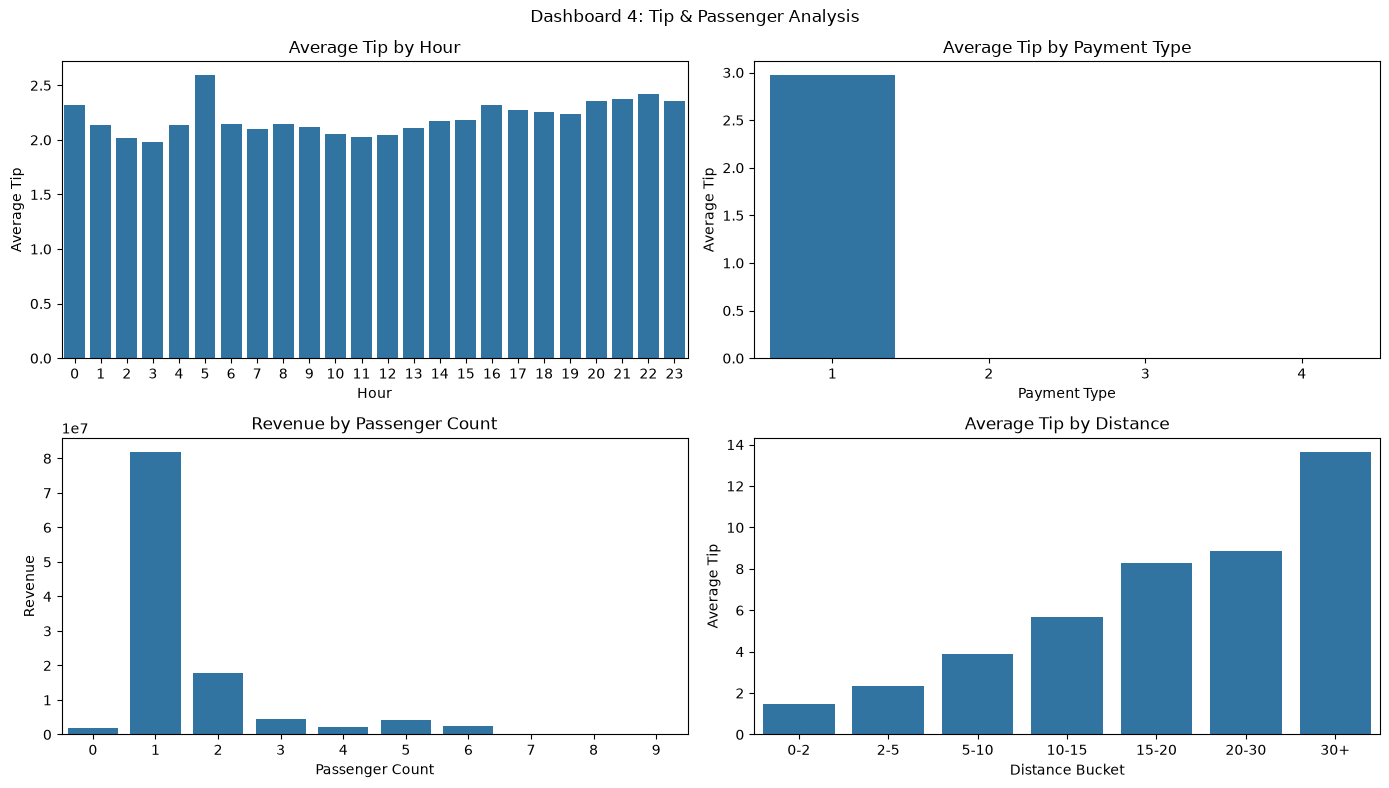

In [45]:
fig, axes = plt.subplots(2,2,figsize=(14,8))
fig.suptitle("Dashboard 4: Tip & Passenger Analysis")

ax1 = sns.barplot(x=hourly_tip_summary['pickup_hour'], y=hourly_tip_summary['avg_tip'], ax=axes[0,0])
ax1.set_title("Average Tip by Hour")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Average Tip")

ax2 = sns.barplot(x=payment_summary['payment_type'], y=payment_summary['avg_tip'], ax=axes[0,1])
ax2.set_title("Average Tip by Payment Type")
ax2.set_xlabel("Payment Type")
ax2.set_ylabel("Average Tip")

ax3 = sns.barplot(x=passenger_summary['passenger_count'], y=passenger_summary['total_revenue'], ax=axes[1,0])
ax3.set_title("Revenue by Passenger Count")
ax3.set_xlabel("Passenger Count")
ax3.set_ylabel("Revenue")

ax4 = sns.barplot(x=distance_tip_summary['distance_bucket'], y=distance_tip_summary['avg_tip'], ax=axes[1,1])
ax4.set_title("Average Tip by Distance")
ax4.set_xlabel("Distance Bucket")
ax4.set_ylabel("Average Tip")

plt.tight_layout()
plt.show()

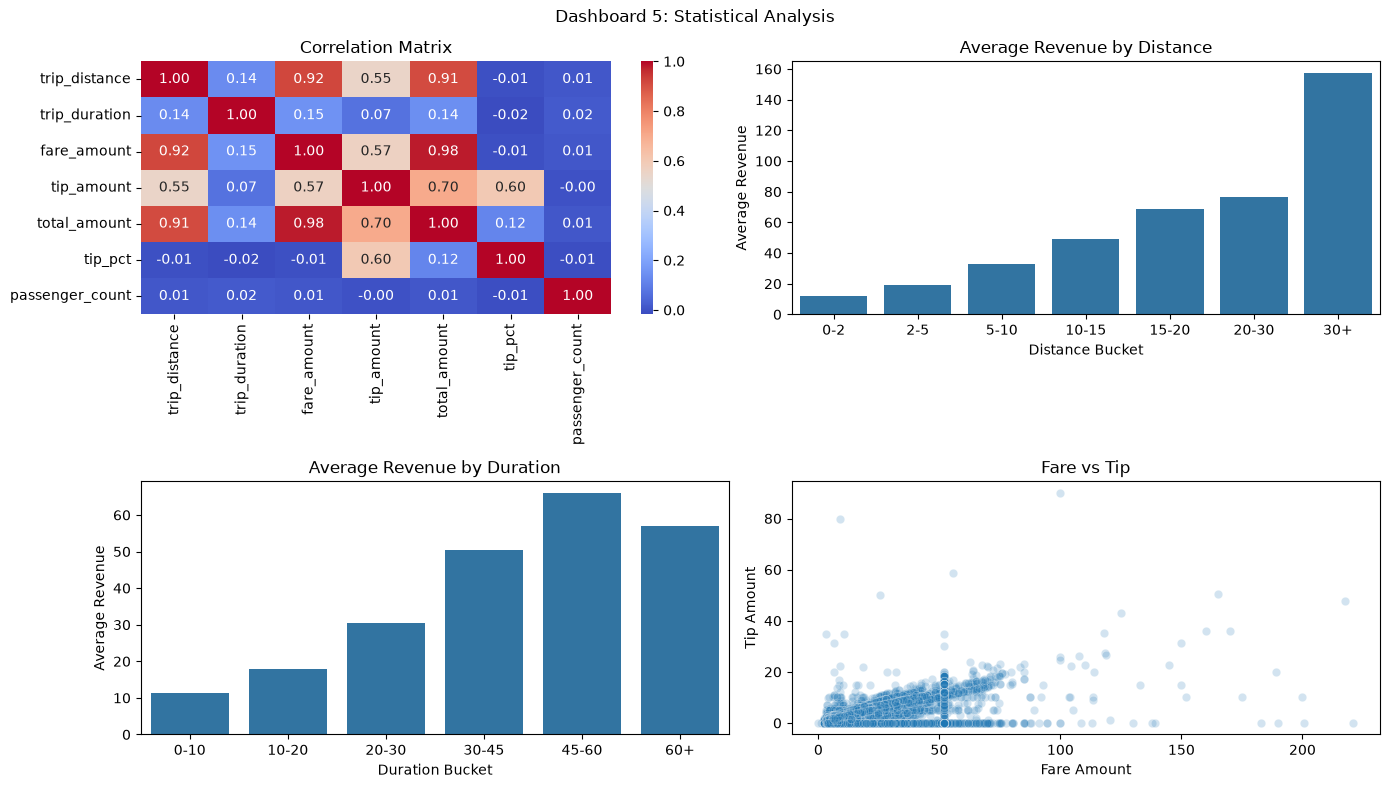

In [46]:
sample_df = df.sample(50000, random_state=42)

corr_cols = ['trip_distance', 'trip_duration', 'fare_amount', 'tip_amount', 'total_amount', 'tip_pct', 'passenger_count']
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle("Dashboard 5: Statistical Analysis")

ax1 = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0,0])
ax1.set_title("Correlation Matrix")

ax2 = sns.barplot(x=distance_summary['distance_bucket'], y=distance_summary['avg_revenue'], ax=axes[0,1])
ax2.set_title("Average Revenue by Distance")
ax2.set_xlabel("Distance Bucket")
ax2.set_ylabel("Average Revenue")

ax3 = sns.barplot(x=duration_summary['duration_bucket'], y=duration_summary['avg_revenue'], ax=axes[1,0])
ax3.set_title("Average Revenue by Duration")
ax3.set_xlabel("Duration Bucket")
ax3.set_ylabel("Average Revenue")

ax4 = sns.scatterplot(data=sample_df, x='fare_amount', y='tip_amount', alpha=0.2, ax=axes[1,1])
ax4.set_title("Fare vs Tip")
ax4.set_xlabel("Fare Amount")
ax4.set_ylabel("Tip Amount")

plt.tight_layout()
plt.show()

In [47]:
# Hypothesis Testing: Do credit card payments yield higher tips than cash payments?

credit_tip = df[df['payment_type'] == 1]['tip_amount']
cash_tip = df[df['payment_type'] == 2]['tip_amount']

t_stat, p_value = ttest_ind(credit_tip, cash_tip, equal_var=False)
print("T Statistic:", t_stat)
print("P Value:", p_value)

# Storing p-value for business conclusion
p_value_ttest = p_value

if p_value < 0.05:
    print("Reject H0: Tip amounts differ significantly.")
else:
    print("Fail to reject H0")

# Hypothesis Testing: Does revenue differ across time periods?

morning = df[df['time_period'] == 'Morning']['total_amount']
afternoon = df[df['time_period'] == 'Afternoon']['total_amount']
evening = df[df['time_period'] == 'Evening']['total_amount']
night = df[df['time_period'] == 'Night']['total_amount']

f_stat, p_value = f_oneway(morning, afternoon, evening, night)

print("F Statistic:", f_stat)
print("P Value:", p_value)

# Storing p-value for business conclusion
p_value_anova = p_value

if p_value < 0.05:
    print("Reject H0: Revenue differs across time periods.")
else:
    print("Fail to reject H0")


'''T-Test Business Conclusion:- Credit card transactions generate significantly higher tip income than cash transactions. Drivers may benefit from encouraging digital payment methods when possible.
ANOVA Business Conclusion:- Revenue differs significantly across time periods, suggesting that driver scheduling can materially impact earnings.'''

T Statistic: 2347.386046603247
P Value: 0.0
Reject H0: Tip amounts differ significantly.
F Statistic: 3565.954752362322
P Value: 0.0
Reject H0: Revenue differs across time periods.


'T-Test Business Conclusion:- Credit card transactions generate significantly higher tip income than cash transactions. Drivers may benefit from encouraging digital payment methods when possible.\nANOVA Business Conclusion:- Revenue differs significantly across time periods, suggesting that driver scheduling can materially impact earnings.'

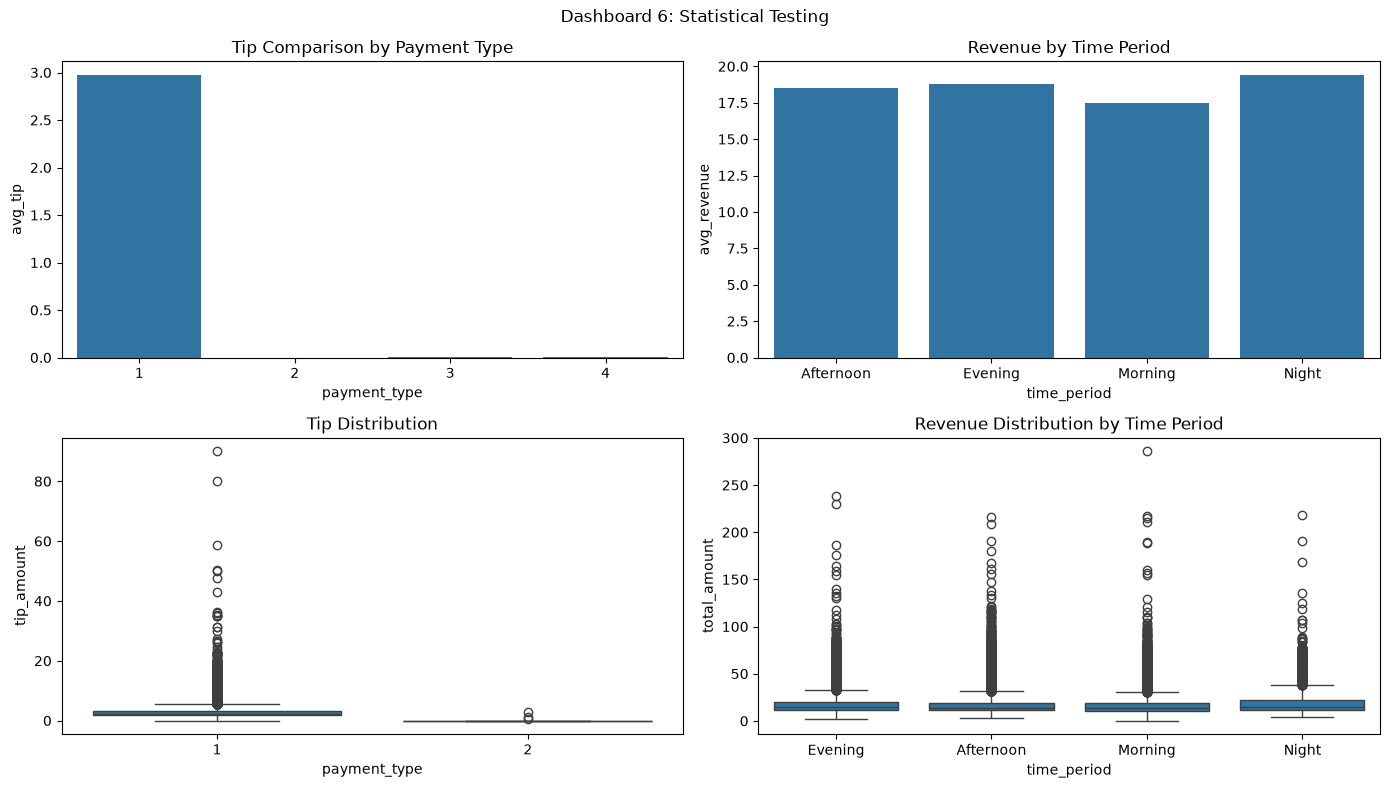

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle("Dashboard 6: Statistical Testing")

ax1 = sns.barplot(x=payment_summary['payment_type'], y=payment_summary['avg_tip'], ax=axes[0,0])
ax1.set_title("Tip Comparison by Payment Type")

ax2 = sns.barplot(data=time_period_summary, x='time_period', y='avg_revenue', ax=axes[0,1])
ax2.set_title("Revenue by Time Period")

ax3 = sns.boxplot(
    data=sample_df[
        sample_df['payment_type'].isin([1,2])
    ],
    x='payment_type',
    y='tip_amount',
    ax=axes[1,0]
)
ax3.set_title("Tip Distribution")

ax4 = sns.boxplot(data=sample_df, x='time_period', y='total_amount', ax=axes[1,1])
ax4.set_title("Revenue Distribution by Time Period")

plt.tight_layout()
plt.show()

In [49]:
print(df['pickup_date'].min())
print(df['pickup_date'].max())
print(df['pickup_date'].nunique())

2020-01-01
2020-01-31
31


In [50]:
print(df['pickup_date'].value_counts().sort_index())
print(df['pickup_date'].sort_values().unique())
print(sorted(df['pickup_date'].unique()))

pickup_date
2020-01-01    166044
2020-01-02    157924
2020-01-03    179213
2020-01-04    179546
2020-01-05    160813
2020-01-06    172863
2020-01-07    194347
2020-01-08    209980
2020-01-09    224671
2020-01-10    220938
2020-01-11    212702
2020-01-12    181553
2020-01-13    204333
2020-01-14    212567
2020-01-15    211949
2020-01-16    234656
2020-01-17    238610
2020-01-18    186666
2020-01-19    172248
2020-01-20    158574
2020-01-21    208680
2020-01-22    216989
2020-01-23    227279
2020-01-24    228377
2020-01-25    219480
2020-01-26    184466
2020-01-27    185219
2020-01-28    210958
2020-01-29    222440
2020-01-30    237964
2020-01-31    231087
Name: count, dtype: int64
[datetime.date(2020, 1, 1) datetime.date(2020, 1, 2)
 datetime.date(2020, 1, 3) datetime.date(2020, 1, 4)
 datetime.date(2020, 1, 5) datetime.date(2020, 1, 6)
 datetime.date(2020, 1, 7) datetime.date(2020, 1, 8)
 datetime.date(2020, 1, 9) datetime.date(2020, 1, 10)
 datetime.date(2020, 1, 11) datetime.date(202

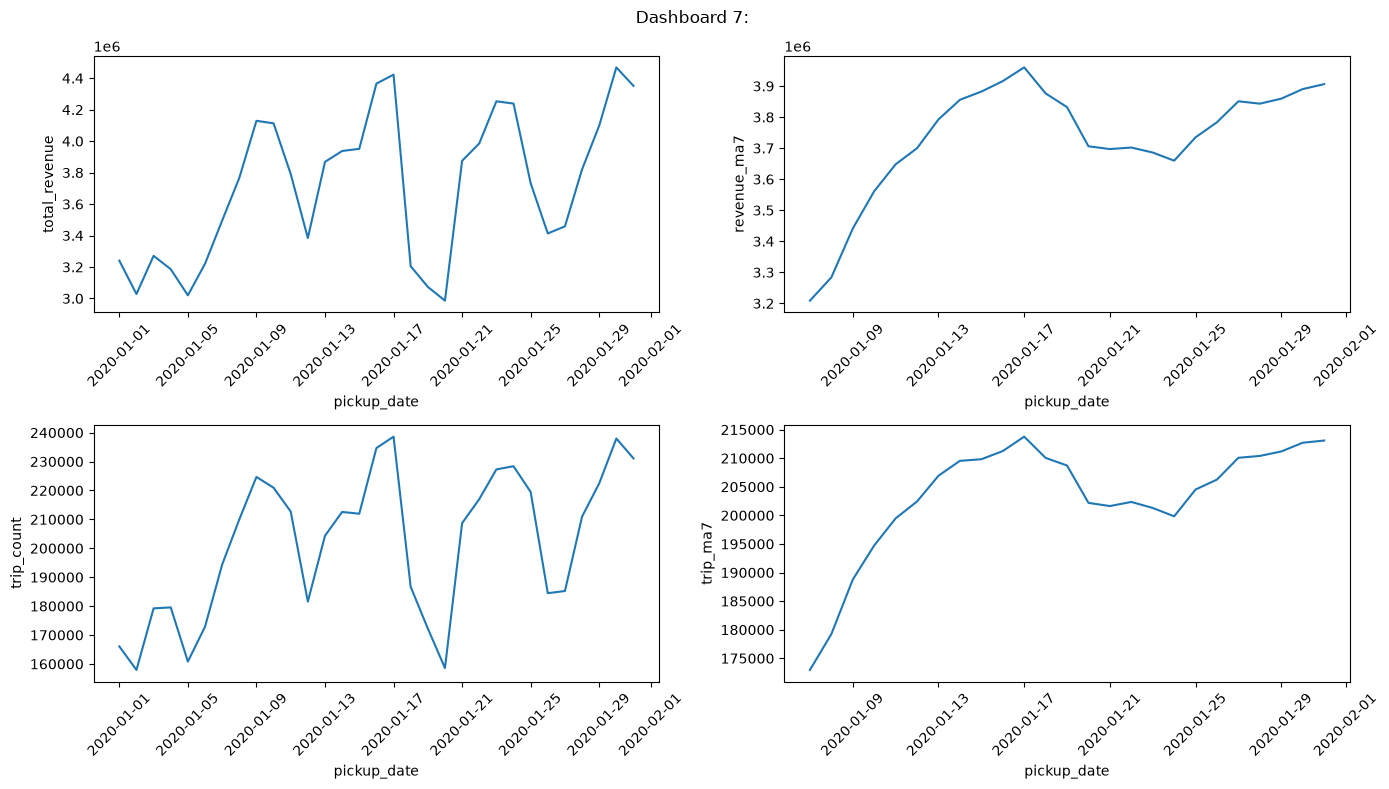

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle("Dashboard 7: ")

ax1 = sns.lineplot(data=daily_summary, x='pickup_date', y='total_revenue', ax=axes[0,0])
ax1.tick_params(axis='x', rotation=45)

ax2 = sns.lineplot(data=daily_summary, x='pickup_date', y='revenue_ma7', ax=axes[0,1])
ax2.tick_params(axis='x', rotation=45)

ax3 = sns.lineplot(data=daily_summary, x='pickup_date', y='trip_count', ax=axes[1,0])
ax3.tick_params(axis='x', rotation=45)

ax4 = sns.lineplot(data=daily_summary, x='pickup_date', y='trip_ma7', ax=axes[1,1])
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [52]:
# Saving the cleaned dataset for power BI dashboard and further analysis
df.to_csv("cleaned_nyc_taxi.csv", index=False)


In [53]:
report = f"""
===========================================================
NYC TAXI DRIVER REVENUE OPTIMIZATION ANALYSIS
===========================================================

===========================================================
EXECUTIVE SUMMARY
===========================================================

This project analyzed over 6.3 million NYC taxi trips to identify
revenue drivers, demand patterns, tipping behavior, passenger trends,
and operational opportunities for taxi drivers.

The project covered:
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Statistical Testing
- Time-Series Analysis
- Business Intelligence Reporting

===========================================================
DASHBOARD 1: EXECUTIVE OVERVIEW
===========================================================

Purpose:
Provide a high-level overview of revenue, demand, and trip distributions.

Key Findings:
- Dataset contains over 6.3 million trips.
- Revenue distribution is highly right-skewed.
- Most trips are short-distance rides.
- Most trips have moderate trip durations.

===========================================================
DASHBOARD 2: DRIVER REVENUE OPTIMIZATION
===========================================================

Key Findings:

- Peak revenue occurs during afternoon and evening hours.
- Weekdays generate higher revenue than weekends.
- Long-distance trips generate substantially higher revenue per trip.
- Medium-duration trips provide the best revenue opportunity.

===========================================================
DASHBOARD 3: DEMAND & OPERATIONS ANALYTICS
===========================================================

Key Findings:

- Ride demand peaks during evening commute hours.
- Fridays generate the highest overall demand.
- Short-distance trips dominate ride volume.
- Most rides last between 0 and 20 minutes.

===========================================================
DASHBOARD 4: TIP & PASSENGER ANALYSIS
===========================================================

Key Findings:

- Credit card users generate significantly higher tips.
- Average tip amount increases with trip distance.
- Single-passenger rides contribute most total revenue.
- Passenger count has limited impact on average trip revenue.
- Longer trips generate larger gratuities.

===========================================================
DASHBOARD 5: CORRELATION & REVENUE DRIVERS
===========================================================

Key Findings:

- Trip distance strongly drives fare amount and revenue.
- Fare amount and total revenue are highly correlated.
- Tip amount is positively associated with fare amount.
- Passenger count has negligible impact on revenue.
- Trip duration influences revenue but less than distance.

===========================================================
DASHBOARD 6: STATISTICAL TESTING
===========================================================

T-Test Results

T Statistic : {t_stat:.2f}
P Value     : {p_value_ttest}

Conclusion:
Credit-card users tip significantly more than cash users.

-----------------------------------------------------------

ANOVA Results

F Statistic : {f_stat:.2f}
P Value     : {p_value_anova}

Conclusion:
Revenue differs significantly across time periods.

===========================================================
DASHBOARD 7: TIME SERIES ANALYSIS
===========================================================

Key Findings:

- Revenue and demand show recurring weekly fluctuations.
- Rolling averages reveal stable operating patterns.
- Demand generally increases through the middle and end of the month.
- Weekend and weekday demand patterns differ consistently.
- Dataset is limited to January 2020, therefore long-term forecasting
  was not performed.

===========================================================
BUSINESS RECOMMENDATIONS
===========================================================

1. Prioritize evening and peak-demand hours.

2. Focus on longer-distance trips when available,
   as they generate higher revenue and tips.

3. Encourage digital payments to maximize gratuity income.

4. Position vehicles in high-demand pickup areas during peak periods.

5. Use demand trends for shift scheduling and planning.

6. Revenue varies significantly across time periods;
   drivers should optimize working hours accordingly.

7. Long-distance trips create higher revenue per ride,
   while short trips drive overall demand volume.

8. Distance is the strongest operational driver of revenue.

===========================================================
PROJECT CONCLUSION
===========================================================

This project demonstrates a complete end-to-end data analytics workflow
covering data cleaning, feature engineering, exploratory analysis,
business intelligence, statistical testing, and time-series analysis.

Key drivers of taxi revenue were found to be:
- Trip Distance
- Fare Amount
- Payment Method
- Time of Day

The analysis provides actionable recommendations for maximizing
driver earnings and improving operational efficiency.

===========================================================
END OF REPORT
===========================================================
"""

with open("business_insights.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("business_insights.txt created successfully")

business_insights.txt created successfully
